# Table of Contents

- [Student Information](#student-information)
  - [Student ID](#student-id)
  - [Demographic Details](#demographic-details)
  - [Study Habits](#study-habits)
- [Parental Involvement](#parental-involvement)
- [Extracurricular Activities](#extracurricular-activities)
- [Academic Performance](#academic-performance)
- [Target Variable: Grade Class](#target-variable-grade-class)

---

## Student Information

### Student ID
- **StudentID**: A unique identifier assigned to each student (1001 to 3392).

### Demographic Details
- **Age**: The age of the students ranges from **15 to 18 years**.
- **Gender**: Gender of the students, where:  
  - `0` → Male  
  - `1` → Female  
- **Ethnicity**: The ethnicity of the students, coded as follows:  
  - `0` → Caucasian  
  - `1` → African American  
  - `2` → Asian  
  - `3` → Other  
- **ParentalEducation**: The education level of the parents, coded as follows:  
  - `0` → None  
  - `1` → High School  
  - `2` → Some College  
  - `3` → Bachelor's  
  - `4` → Higher  

### Study Habits
- **StudyTimeWeekly**: Weekly study time in hours, ranging from **0 to 20**.
- **Absences**: Number of absences during the school year, ranging from **0 to 30**.
- **Tutoring**: Tutoring status, where:  
  - `0` → No  
  - `1` → Yes  

---

## Parental Involvement
- **ParentalSupport**: The level of parental support, coded as follows:  
  - `0` → None  
  - `1` → Low  
  - `2` → Moderate  
  - `3` → High  
  - `4` → Very High  

---

## Extracurricular Activities
- **Extracurricular**: Participation in extracurricular activities, where:  
  - `0` → No  
  - `1` → Yes  
- **Sports**: Participation in sports, where:  
  - `0` → No  
  - `1` → Yes  
- **Music**: Participation in music activities, where:  
  - `0` → No  
  - `1` → Yes  
- **Volunteering**: Participation in volunteering, where:  
  - `0` → No  
  - `1` → Yes  

---

## Academic Performance
- **GPA**: Grade Point Average on a scale from **2.0 to 4.0**, influenced by study habits, parental involvement, and extracurricular activities.

---

## Target Variable: Grade Class
- **GradeClass**: Classification of students' grades based on GPA:  
  - `0` → 'A' (**GPA ≥ 3.5**)  
  - `1` → 'B' (**3.0 ≤ GPA < 3.5**)  
  - `2` → 'C' (**2.5 ≤ GPA < 3.0**)  
  - `3` → 'D' (**2.0 ≤ GPA < 2.5**)  
  - `4` → 'F' (**GPA < 2.0**)  


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
import numpy as np


In [71]:
df=pd.read_csv("/kaggle/input/students-performance-dataset/Student_performance_data _.csv")
df.head(1)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0


| **Quantitative Variables**      | **Qualitative Variables**    |
|--------------------------------|-----------------------------|
| **Age** (Continuous)           | **Gender** (Nominal)        |
| **StudyTimeWeekly** (Continuous) | **Ethnicity** (Nominal)     |
| **Absences** (Discrete)        | **ParentalEducation** (Ordinal) |
| **GPA** (Continuous)           | **Tutoring** (Nominal)      |
|                                | **ParentalSupport** (Ordinal) |
|                                | **Extracurricular** (Nominal) |
|                                | **Sports** (Nominal)        |
|                                | **Music** (Nominal)         |
|                                | **Volunteering** (Nominal)  |
|                                | **GradeClass** (Ordinal) *(Derived from GPA)* |


In [10]:
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

In [14]:
df.isna().sum().sum()

np.int64(0)

As we can see there is no missing values here so we are good to go

<Axes: >

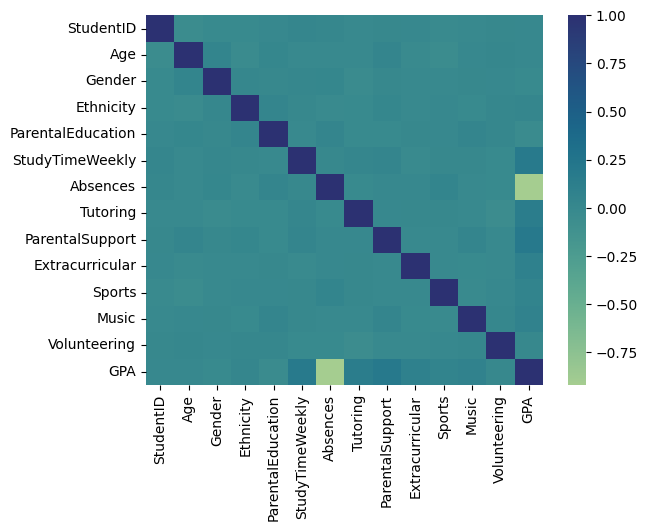

In [19]:
sns.heatmap(data=df.drop(columns=['GradeClass']).corr(),cmap="crest")

As we can see there is strong negative correlation between **GPA** and **Absences**

In [160]:
df.head(1)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0


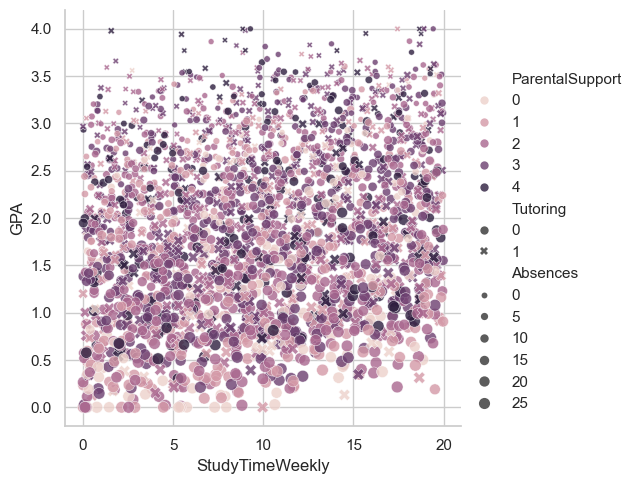

In [48]:
sns.set_theme(style="whitegrid")
g=sns.relplot(
    data=df, 
    x='StudyTimeWeekly', 
    y='GPA', 
    size='Absences', 
    style='Tutoring', 
    hue='ParentalSupport',
    alpha=0.8
)




#### The scatter plot does not provide many useful insights, as there is no clear pattern or strong correlation between the variables. This suggests that other factors may play a more significant role in influencing GPA.


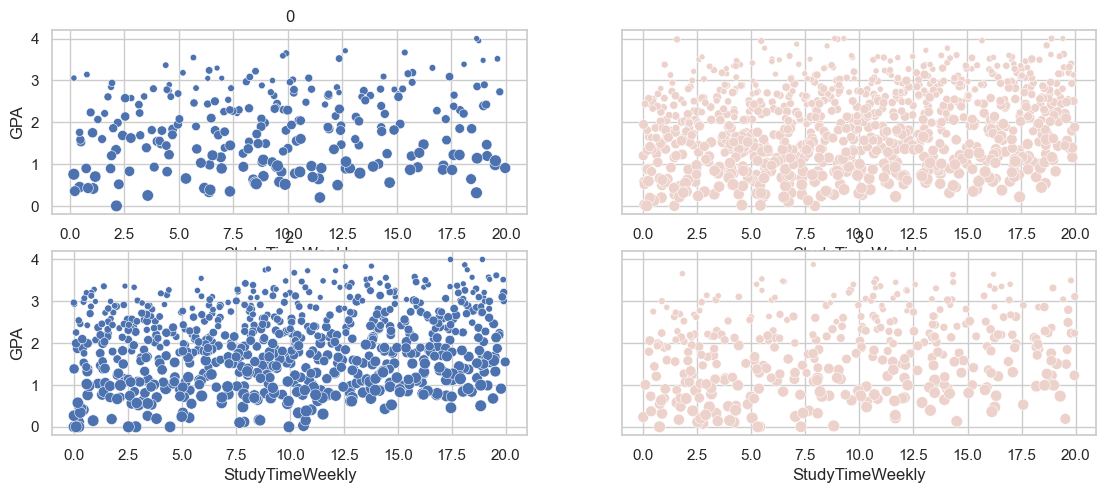

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharey=True)

sns.scatterplot(df[df['ParentalEducation']==0],x='StudyTimeWeekly',y='GPA',hue='ParentalEducation',size='Absences',legend=False,ax=axes[0,0])  
axes[0,0].set_title('0')
sns.scatterplot(data=df[df['ParentalEducation'] == 1], x='StudyTimeWeekly', y='GPA', hue='ParentalEducation',size='Absences',legend=False, ax=axes[1,0])
axes[1,1].set_title("1")
sns.scatterplot(df[df['ParentalEducation']==2],x='StudyTimeWeekly',y='GPA',hue='ParentalEducation',size='Absences',legend=False,ax=axes[0,1])  
axes[1,0].set_title('2')
sns.scatterplot(data=df[df['ParentalEducation'] == 3], x='StudyTimeWeekly', y='GPA', hue='ParentalEducation',size='Absences',legend=False, ax=axes[1,1])
axes[1,1].set_title("3")




plt.show()


#### Even when we divide the scatter plot by parental education levels, there is still no clear pattern. This suggests that parental education alone does not strongly influence the relationship between study time and GPA.


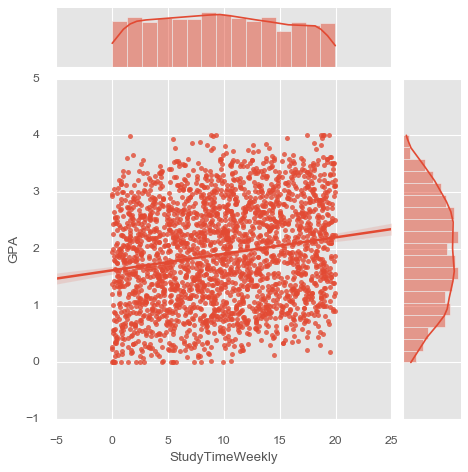

In [159]:
sns.set_theme(style="darkgrid")
plt.style.use('ggplot')
sns.jointplot(data=df,y='GPA',x='StudyTimeWeekly',kind='reg',truncate=False,)

## **Relationship Between GPA and Study Time**  

From the **regression line**, we observe a **slight positive correlation** between **GPA and Study Time Weekly**. Additionally, we note that:  

- **Study time appears to be uniformly distributed**, which makes sense since approximately **50% of students pass** and **50% fail**.  
- **GPA follows a normal distribution**, which is also logical, as **achieving a very high GPA is difficult, and very few students get a GPA of 0**.  
- **Study time does not have a strong correlation with GPA**, as some students **study less but perform well**, while others **study more but achieve lower results**, effectively **balancing out the correlation**.


In [12]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

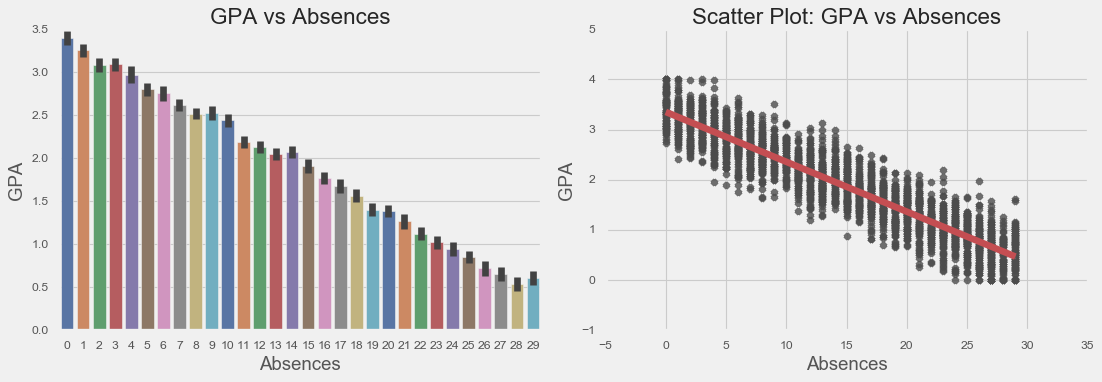

In [165]:


cols = ['Absences']

plt.style.use('fivethirtyeight')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for Absences vs. GPA
for col in cols:
    sns.barplot(data=df, x=df[col], y=df['GPA'], hue=df[col], palette='deep', ax=axes[0],legend=False)
    axes[0].set_title("GPA vs Absences")
    axes[0].set_xlabel("Absences")
    axes[0].set_ylabel("GPA")

# Scatter plot with regression line for Absences vs. GPA
sns.regplot(data=df, x='Absences', y='GPA', ci=99, marker="x", color=".3", line_kws=dict(color="r"), ax=axes[1])
axes[1].set_title("Scatter Plot: GPA vs Absences")
axes[1].set_xlabel("Absences")
axes[1].set_ylabel("GPA")

plt.tight_layout()
plt.show()



## **Relationship Between GPA and Absences**  

As we can see from this **bar plot**, there is a **strong negative correlation** between **GPA and absences**, which aligns with the trend observed earlier in the **heatmap**. This suggests that **higher absences are associated with lower GPA**, reinforcing the importance of consistent attendance for academic success.


<Axes: xlabel='Tutoring', ylabel='count'>

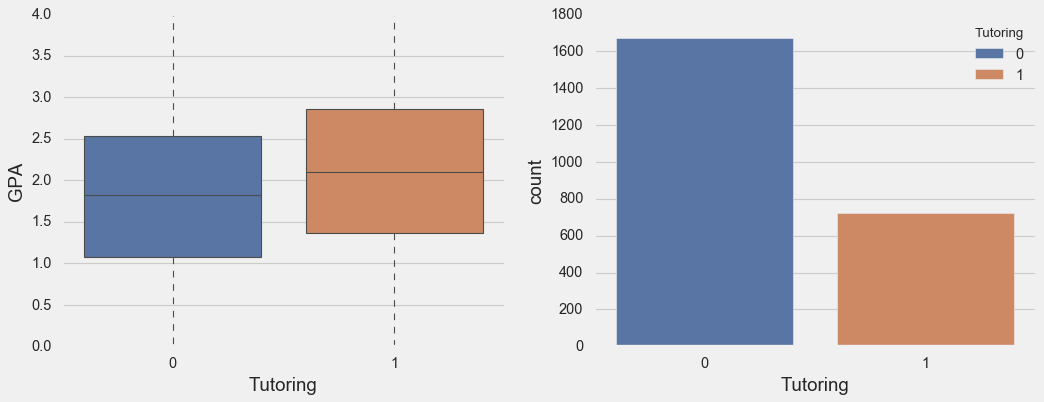

In [ ]:
fig ,axes=plt.subplots(1,2,figsize=(14,5))
plt.style.use('fivethirtyeight')

sns.boxplot(data=df,x=df['Tutoring'],y=df['GPA'],hue=df['Tutoring'],palette='deep',legend=False,ax=axes[0])
sns.countplot(data=df,x=df['Tutoring'],hue='Tutoring',palette='deep',ax=axes[1])

## **Analysis of Tutoring and Student Performance**

From the **box plot** on the left, we observe that **students who receive tutoring tend to have slightly better performance** compared to those who do not. However, the difference is not very significant.  

On the **count plot** to the right, we see that approximately **one-third of students participate in tutoring**, while the remaining two-thirds do not.  

While tutoring appears to provide a small performance boost, **its true effectiveness remains uncertain**. Several factors could explain this trend:  

- **Self-selection bias**: Students who are already academically motivated may be more likely to seek tutoring, meaning their improved performance could be due to their own study habits rather than tutoring itself.  
- **Alternative explanations**: These high-performing students might have achieved similar results through **self-study** alone.  
- **Financial factors**: Since tutoring often comes at a cost, students with **greater parental support** may have more access to it, which could indirectly contribute to better performance.  

Thus, while tutoring **may be beneficial**, further analysis is needed to determine whether it is the primary driver of improved performance or if other underlying factors play a larger role.


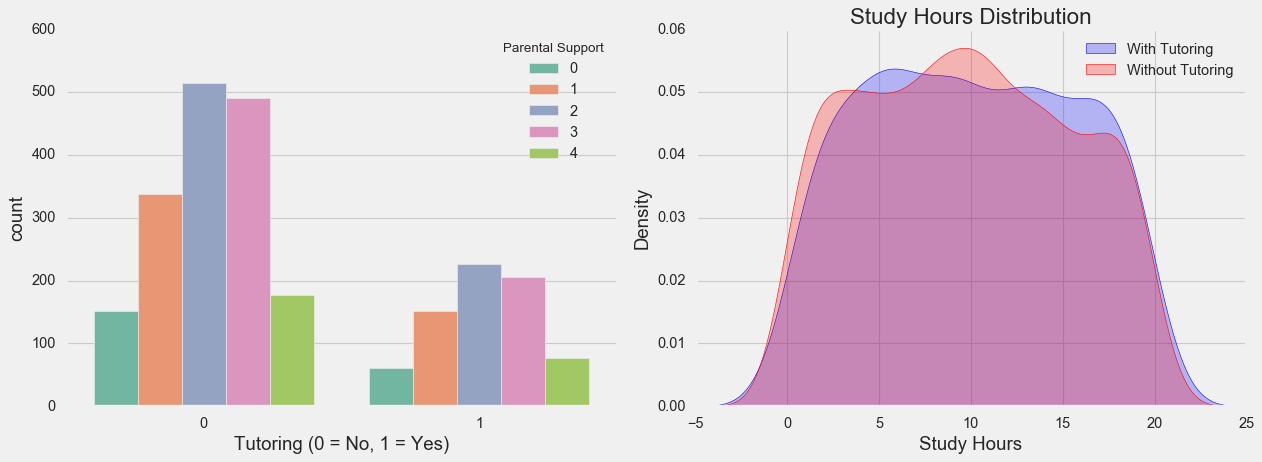

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))  



sns.kdeplot(df[df["Tutoring"] == 1]["StudyTimeWeekly"], label="With Tutoring", fill=True, color="blue", ax=axes[1])
sns.kdeplot(df[df["Tutoring"] == 0]["StudyTimeWeekly"], label="Without Tutoring", fill=True, color="red", ax=axes[1])
axes[1].set_xlabel("Study Hours")
axes[1].set_ylabel("Density")
axes[1].set_title("Study Hours Distribution")
axes[1].legend()

sns.countplot(x="Tutoring", hue="ParentalSupport", data=df, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Tutoring (0 = No, 1 = Yes)")


axes[0].legend(title="Parental Support")

plt.tight_layout()
plt.show()


## **Tutoring, Study Hours, and Parental Support in Student Performance**  

We previously assumed that students who participate in tutoring might be **academically motivated** or generally **strong students** who struggle with certain subjects. This is supported by the **study hours distribution**, where students receiving tutoring tend to **study more hours per week**. Over time, this increased study time **contributes to improved GPA performance**.  

Regarding parental support, we initially hypothesized that students with **higher parental support** might be more likely to attend tutoring due to financial aid. However, the **count plot** now shows that the **distribution of students with parental support is similar between those who do and do not attend tutoring**. This suggests that **parental support does not significantly influence a student's decision to participate in tutoring**.  

Since **only about one-third of students receive tutoring**, we observe a similar pattern in the count distribution—reinforcing that tutoring participation is **not directly tied to parental support but rather to individual academic needs**.


<Axes: xlabel='StudyTimeWeekly', ylabel='GPA'>

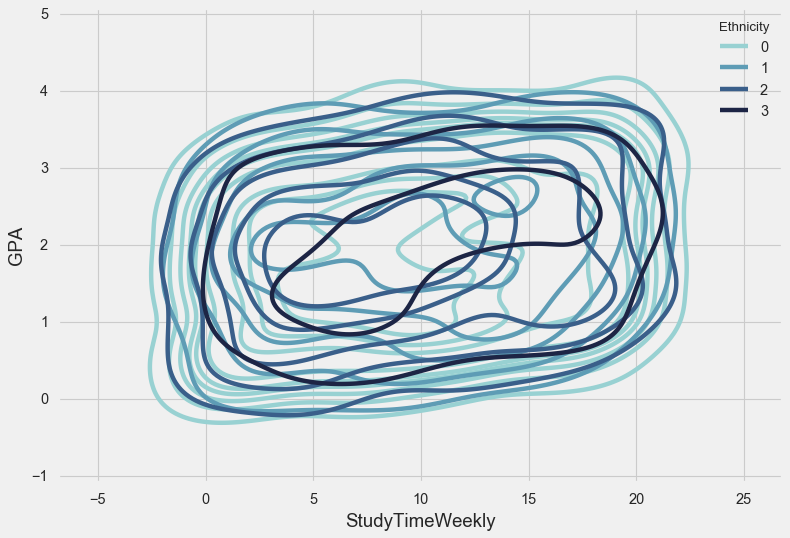

In [81]:
sns.kdeplot(data=df,x='StudyTimeWeekly',y='GPA',hue='Ethnicity',palette="ch:rot=-.25,hue=1,light=.75")

### **Analysis of Ethnicity Distribution in Rankings**

From the KDE graph, we observe that **Ethnicity 0 (Caucasian)** appears both at the **highest and lowest positions** in the GPA. This suggests that individuals from this group are **spread across the performance spectrum**.  

On the other hand, **Ethnicity 3** (which includes all races other than **Caucasian, African American, and Asian**) tends to **cluster around the mean**.  

However, we **cannot draw definitive conclusions** based solely on the count of each racial group. The observed distribution might be influenced by the fact that **Caucasians form the majority**, which naturally increases their representation across different ranking levels.  


<Axes: xlabel='Ethnicity', ylabel='GPA'>

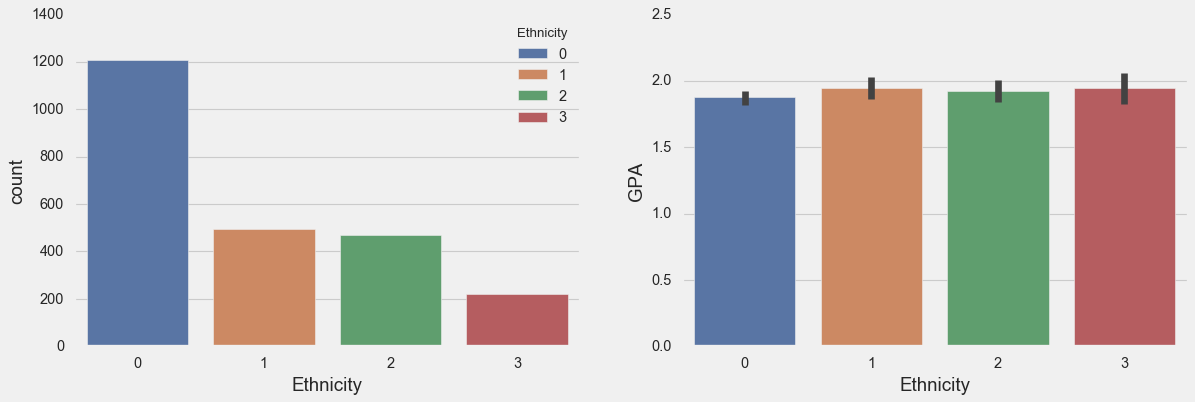

In [119]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df,x='Ethnicity',palette='deep',hue=col,ax=axes[0])
sns.barplot(data=df,x=df[col],y=df['GPA'],hue=df[col],palette='deep',legend=False,ax=axes[1])




### **Impact of Ethnicity and Parental Support on Student Performance**  

As mentioned earlier, the **KDE plot was influenced by the majority representation of the Caucasian ethnicity**, which in turn affected our conclusions. However, based on this analysis, we **cannot conclude that race has any significant impact on student performance**.  

On the other hand, **parental support** appears to have a **positive effect** on student performance, suggesting that factors such as **guidance, motivation, and the learning environment** may play a more crucial role in academic success.  

Additionally, from the **graph on the right**, we observe that **ethnicity has little to no influence on student performance**, further reinforcing the idea that other factors, such as parental involvement, may be more relevant in determining academic outcomes.  


<Axes: xlabel='ParentalEducation', ylabel='count'>

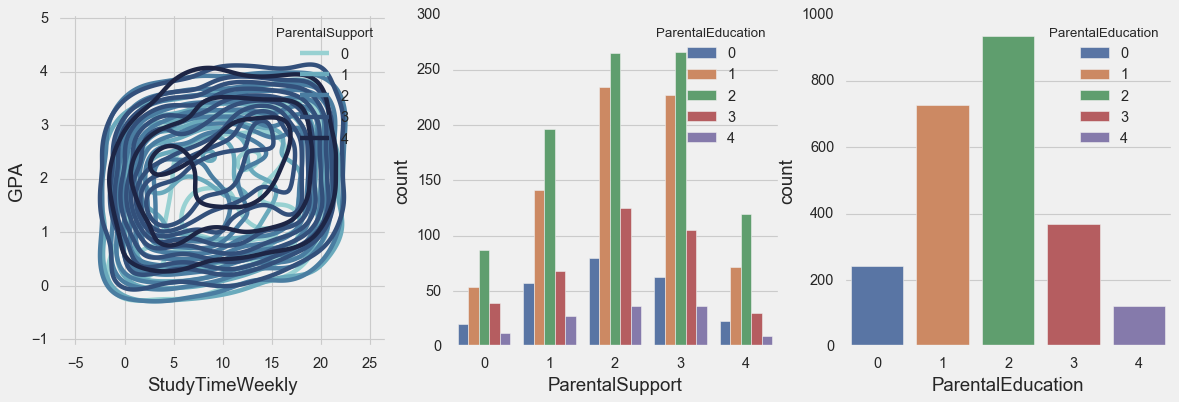

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.kdeplot(data=df,x='StudyTimeWeekly',y='GPA',hue='ParentalSupport',palette="ch:rot=-.25,hue=1,light=.75",ax=axes[0])
sns.countplot(data=df,x='ParentalSupport',hue='ParentalEducation',palette='deep',ax=axes[1])
sns.countplot(data=df,x='ParentalEducation',hue='ParentalEducation',palette='deep',ax=axes[2])

### **Analysis of Parental Support and Education on Student Performance**  

From the **KDE plot**, we observe that **very high parental support** leads to a **slight increase in student performance**. Intuitively, we might expect that parents with **higher education levels** would dominate the **high parental support** category, assuming they have greater financial and educational resources.  

However, this is **not the case**. The distribution of **parental education** is **similar across all levels of parental support**, meaning that **higher-educated parents are not necessarily providing the most support**. In fact, within the **high parental support category**, parents with **higher education levels are the least represented**.  

This suggests that **parental support is not solely influenced by education level**, and other factors—such as time availability, personal beliefs, or work commitments—may play a role in how much support parents provide for their children’s education.


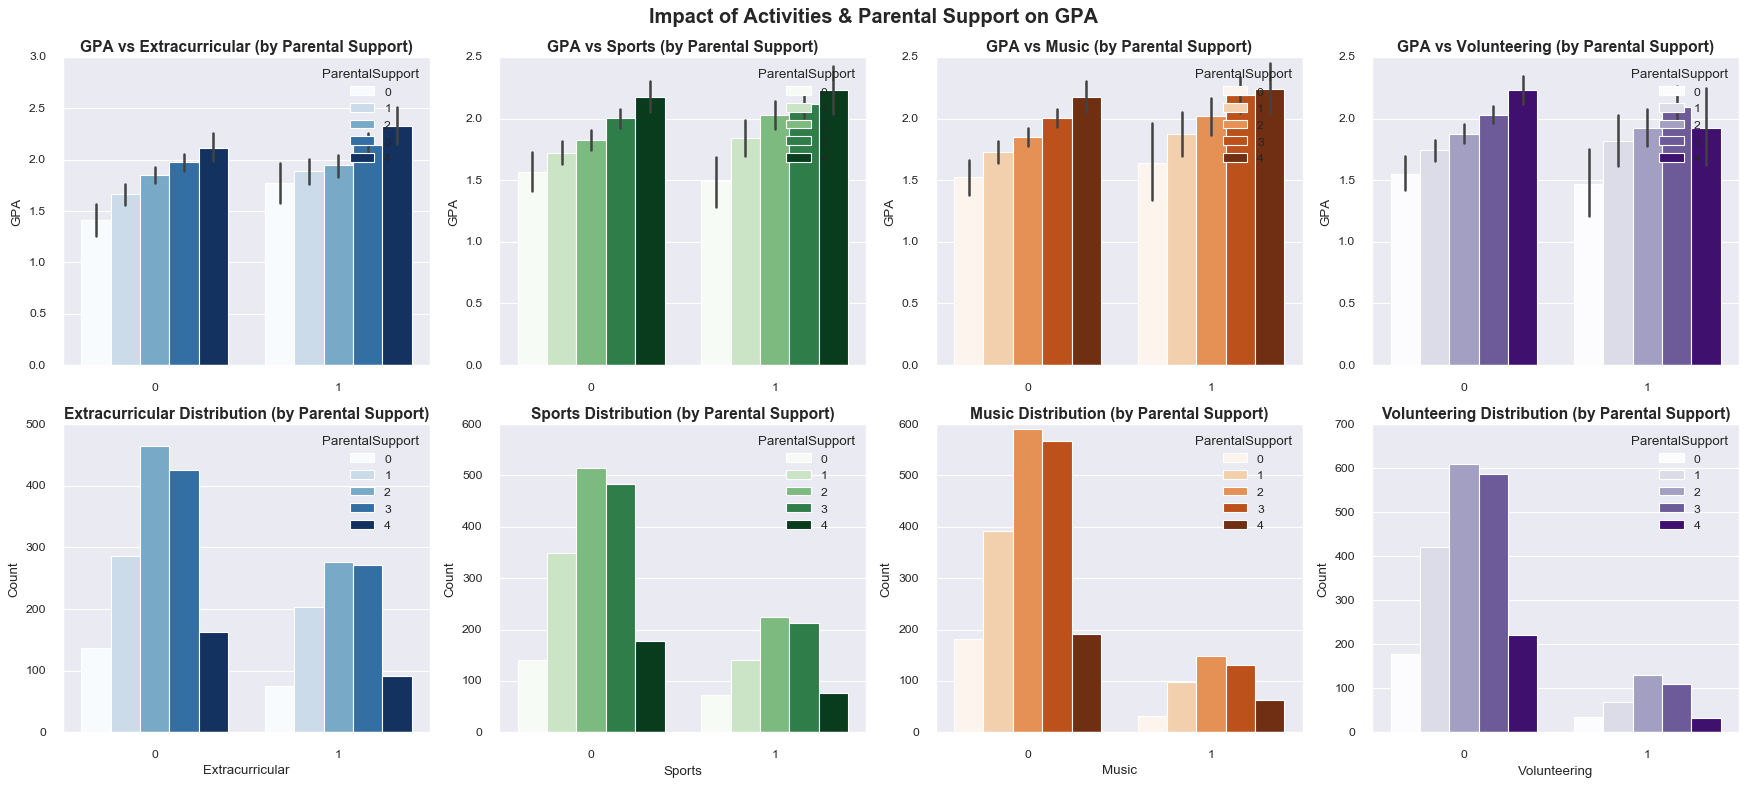

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

activities = ['Extracurricular', 'Sports', 'Music', 'Volunteering']
titles = ["GPA vs Extracurricular", "GPA vs Sports", "GPA vs Music", "GPA vs Volunteering"]
colors = ["Blues", "Greens", "Oranges", "Purples"]

for i, (ax_bar, ax_count, activity, title, color) in enumerate(zip(axes[0], axes[1], activities, titles, colors)):
    sns.barplot(data=df, x=activity, y='GPA', hue="ParentalSupport", palette=color, ax=ax_bar)
    ax_bar.set_title(f"{title} (by Parental Support)", fontsize=14, fontweight='bold')
    ax_bar.set_xlabel("")
    ax_bar.set_ylabel("GPA", fontsize=12)
    
    sns.countplot(data=df, x=activity, hue="ParentalSupport", palette=color, ax=ax_count)
    ax_count.set_title(f"{activity} Distribution (by Parental Support)", fontsize=14, fontweight='bold')
    ax_count.set_xlabel(activity, fontsize=12)
    ax_count.set_ylabel("Count", fontsize=12)

plt.suptitle("Impact of Activities & Parental Support on GPA", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


### Analysis of Parental Support & Extracurricular Activities on GPA

As we can see from this graph, **parental support does not have a significant relationship** with activities such as **Sports, Extracurriculars, Music, and Volunteering**. However, **all activities except Volunteering** show a **slight increase in GPA and academic performance**.

The key question we ask now is:  
- **Do students with high GPA engage in these activities, or do these activities help students improve their GPA?**  

Based on our previous findings, the answer is **both**. However, in general, **students with higher GPA tend to participate in more activities than other students**.
